In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap

EMB_PATH = "/home/andrew.dickson/svar/sativas413_embeddings.ckpt.pt"

/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
data = torch.load(EMB_PATH, weights_only=True)
fingerprints = list(w for w in data.keys())
emb_stack = torch.stack([data[k] for k in fingerprints])
windows = list(set([w[:3] for w in fingerprints]))
window_ind = {w: i for i, w in enumerate(windows)}
emb_window_ind = torch.tensor([window_ind[w[:3]] for w in fingerprints])

In [39]:
emb_stack.dtype

torch.float32

In [37]:
var_val = []
for i in range(2000):
    we = emb_stack[emb_window_ind == i]
    we_var = we.var(dim=0)
    var_val.append(we_var.sum())

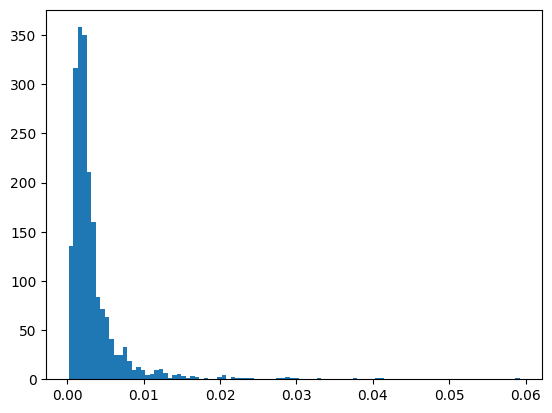

In [38]:
plt.hist(var_val, bins=100)
plt.show()

In [ ]:
windows = set([w[:3] for w in data.keys()])
from collections import defaultdict
alt_alleles = defaultdict(list)
alt_emb = defaultdict(list)
for chrom, si, ei, alt_tup in data.keys():
    alt_alleles[(chrom, si, ei)].append(alt_tup)
    alt_emb[(chrom, si, ei)].append(alt_emb)

In [10]:
emb_stack = torch.stack([emb for emb in data.values()])
emb_stack.shape

torch.Size([68984, 768])

In [25]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
coords  = reducer.fit_transform(emb_stack)
print("UMAP done:", coords.shape)

/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done: (68984, 2)


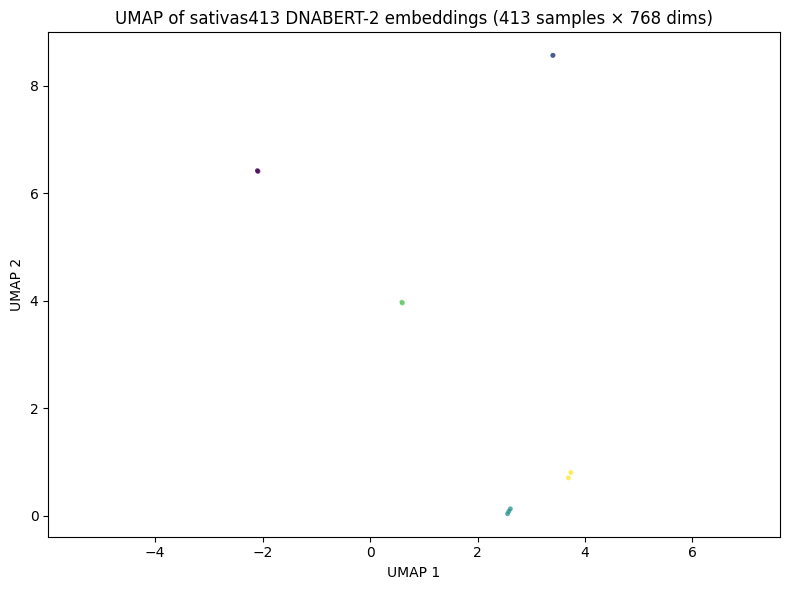

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))
emb_subset = coords[emb_window_ind < 5]
subset_windows = emb_window_ind[emb_window_ind < 5]

sc = ax.scatter(emb_subset[:, 0], emb_subset[:, 1], c=subset_windows, s=12, alpha=0.75, linewidths=0)

ax.set_title("UMAP of sativas413 DNABERT-2 embeddings (413 samples × 768 dims)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_aspect("equal", "datalim")

plt.tight_layout()
plt.show()

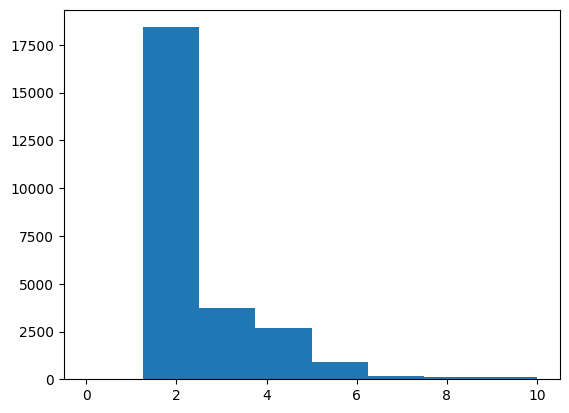

In [5]:
plt.hist([len(v) for v in alt_emb.values()], bins=np.linspace(0, 10, 9))
plt.show()

In [ ]:
from itertools import islice
print(list(islice(data.keys(), 35)))

[(1, 14096, 15096, ()), (1, 14096, 15096, (14146,)), (1, 74141, 75141, ()), (1, 74141, 75141, (74191,)), (1, 75918, 76918, ()), (1, 75918, 76918, (76851,)), (1, 75918, 76918, (75968,)), (1, 76902, 77902, ()), (1, 76902, 77902, (76952,)), (1, 91965, 92965, ()), (1, 91965, 92965, (92015,)), (1, 147574, 148574, ()), (1, 147574, 148574, (147624,)), (1, 149954, 150954, ()), (1, 149954, 150954, (150004, 150753)), (1, 149954, 150954, (150004,)), (1, 149954, 150954, (150753,)), (1, 152441, 153441, ()), (1, 152441, 153441, (152491,)), (1, 153848, 154848, ()), (1, 153848, 154848, (153898,)), (1, 173704, 174704, ()), (1, 173704, 174704, (174691,)), (1, 173704, 174704, (173922,)), (1, 173704, 174704, (173754, 174691)), (1, 174641, 175641, ()), (1, 174641, 175641, (174691,)), (1, 196276, 197276, ()), (1, 196276, 197276, (196326,)), (1, 199960, 200960, ()), (1, 199960, 200960, (200010,)), (1, 203948, 204948, ()), (1, 203948, 204948, (204125,)), (1, 203948, 204948, (203998, 204125)), (1, 203948, 2049

In [26]:
# ── Embedding variance diagnostic ──────────────────────────────────────────────
# If SNPs weren't incorporated, all sample embeddings will be nearly identical
# (differing only by floating-point noise). These numbers distinguish that from
# genuine but low-dimensional variation.

per_dim_std = embeddings_centered.std(axis=0)          # std across samples per dim
mean_l2     = np.linalg.norm(embeddings_centered, axis=1).mean()  # mean L2 from centroid

# Sample 200 random pairs and compute L2 distances
rng  = np.random.default_rng(0)
idx  = rng.integers(0, len(embeddings_centered), size=(200, 2))
pair_dists = np.linalg.norm(
    embeddings_centered[idx[:, 0]] - embeddings_centered[idx[:, 1]], axis=1
)

print(f"Per-dim std  — mean: {per_dim_std.mean():.5f}  max: {per_dim_std.max():.5f}")
print(f"Mean L2 from centroid : {mean_l2:.5f}")
print(f"Pairwise L2 — mean: {pair_dists.mean():.5f}  max: {pair_dists.max():.5f}")
print()
print("Interpretation:")
print("  If pairwise L2 ≈ 0 → embeddings are identical → SNPs not being applied")
print("  If pairwise L2 > 0 but small → SNPs applied but window context dominates")

Per-dim std  — mean: 0.00004  max: 0.00317
Mean L2 from centroid : 0.00291
Pairwise L2 — mean: 0.00388  max: 0.01167

Interpretation:
  If pairwise L2 ≈ 0 → embeddings are identical → SNPs not being applied
  If pairwise L2 > 0 but small → SNPs applied but window context dominates


In [27]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
coords  = reducer.fit_transform(embeddings_centered)
print("UMAP done:", coords.shape)

/home/adickson/miniconda3/envs/svar/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done: (413, 2)


In [28]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=50, min_dist=0.03)
coords  = reducer.fit_transform(embeddings)   # (413, 2)
print("UMAP done:", coords.shape)

/home/adickson/miniconda3/envs/svar/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done: (413, 2)


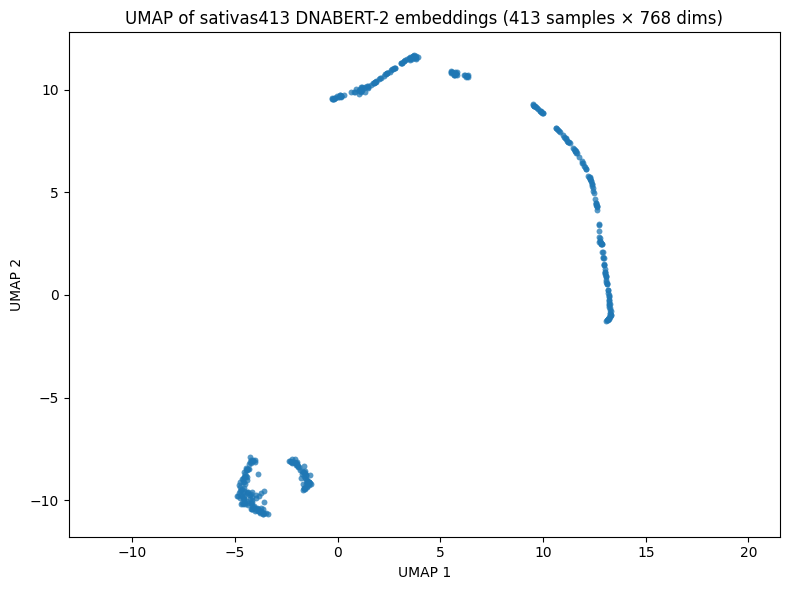

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(coords[:, 0], coords[:, 1], s=18, alpha=0.75, linewidths=0)

ax.set_title("UMAP of sativas413 DNABERT-2 embeddings (413 samples × 768 dims)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_aspect("equal", "datalim")

plt.tight_layout()
plt.show()